In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
# matplotlib.use('TkAgg')  # Alternative: 'Qt5Agg'

/var/folders/kg/2vryh0qs20ncmg9p8d06t7nc0000gn/T/ipykernel_5455/4247020738.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [10]:
"""
    Plot singularity data:
    1.)  current vs. goal position and highlight 
    2.)  orientation error and highlight 
    3.)  s-value ratios and highlight w/ bars 
    4.)  singular vs. non-singular task torques (single joint) and highlight

    Data: 	
    logger.addToLog(robot_q, "robot_q");
	logger.addToLog(robot_dq, "robot_dq");
	logger.addToLog(ee_pos, "ee_pos");
	logger.addToLog(goal_pos, "goal_pos");
	logger.addToLog(svalues, "svalues");
    logger.addToLog(singular_task_torques, "singular_task_torques");
	logger.addToLog(motion_force_task_torques, "motion_task_torques");
	logger.addToLog(alpha, "alpha");
	logger.addToLog(ori_error, "ori_error");
    logger.addToLog(singular_direction, "singular_direction");
"""

'\n    Plot singularity data:\n    1.)  current vs. goal position and highlight \n    2.)  orientation error and highlight \n    3.)  s-value ratios and highlight w/ bars \n    4.)  singular vs. non-singular task torques (single joint) and highlight\n\n    Data: \t\n    logger.addToLog(robot_q, "robot_q");\n\tlogger.addToLog(robot_dq, "robot_dq");\n\tlogger.addToLog(ee_pos, "ee_pos");\n\tlogger.addToLog(goal_pos, "goal_pos");\n\tlogger.addToLog(svalues, "svalues");\n    logger.addToLog(singular_task_torques, "singular_task_torques");\n\tlogger.addToLog(motion_force_task_torques, "motion_task_torques");\n\tlogger.addToLog(alpha, "alpha");\n\tlogger.addToLog(ori_error, "ori_error");\n    logger.addToLog(singular_direction, "singular_direction");\n'

In [129]:
# plot options 
# TYPE_1_OPT = True 
# TYPE_2_OVERHEAD_OPT = False 
# TYPE_2_WRIST_OPT = False 
PLOT_OPT = [1, 0, 0]
YLABELS = ["X (m)", "Y (m)", "Z (m)"]
ORI_YLABELS = ["X (rad)", "Y (rad)", "Z (rad)"]
LABELS = ["Type 1 and 2 Singularities"]
# START_INDICES = [1500 + 169, 3328, 469]
START_INDICES = [400, 400, 0]
# END_INDICES = [-1, 3328 + 3000, -1]
END_INDICES = [400 + 400, 400 + 3800, -1]

# csv_file = '../../build/examples/18-panda_singularity/type_1.csv'
# csv_file = './data/03-31/revised-bounds/type_1 copy.csv'
# csv_file = './data/03-31/revised-bounds/type_2_wrist.csv'
# csv_file = './data/03-26/type_2_overhead.csv'
# csv_file = '../../build/examples/18-panda_singularity/type_1.csv'
# csv_file = '../../build/examples/18-panda_singularity/type_2_wrist.csv'
# csv_file = './data/04-08/type_2_wrist_pos.csv'
# csv_file = './data/04-04/type_2_wrist_with_vel.csv'
# csv_file = '../../build/examples/18-panda_singularity/type_2_wrist.csv'
csv_file = '../../build/tests/01-puma/puma.csv'
# csv_file = './data/12-30/type_1.csv'
# csv_file = './data/12-30/type_2_wrist.csv'
# csv_file = './data/puma.csv'
# csv_file = './data/puma_rev3.csv'
joint_index = 0
exp_index = 0

In [130]:
# s values 
# combined_s_values = [7e-3, 7e-2]
# combined_s_values = [4e-2, 7e-2]
# linear_s_values = [3e-2, 3e-1]
combined_s_values = [5e-2, 5e-2]

In [131]:
# Load CSV file
# def plot(csv_file, joint_index, exp_index):
df = pd.read_csv(csv_file)   

# Drop 'timestamp' column if it exists
if 'timestamp' in df.columns:
    df = df.drop(columns=['timestamp'])  

# Convert 'time' column to float
df['time'] = df['time'].astype(float)  

# Extract data columns 
ee_pos_columns = [col for col in df.columns if 'ee_pos' in col]  
goal_pos_columns = [col for col in df.columns if 'goal_pos' in col]
ori_error_columns = [col for col in df.columns if 'ori_error' in col]
svalue_columns = [col for col in df.columns if 'svalues' in col]
singular_task_torques_columns = [col for col in df.columns if 'singular_task_torques' in col]
motion_task_torques_columns = [col for col in df.columns if 'motion' in col]
alpha_columns = [col for col in df.columns if 'alpha' in col]
non_singular_task_torques_columns = [col for col in df.columns if 'non_singular_task_torques' in col]
joint_strategy_torques_columns = [col for col in df.columns if 'singular_joint_space_torques' in col]
# nonhandling_torque_columns = [col for col in df.columns if 'nonhandling' in col]
nonhandling_torque_columns = [col for col in df.columns if 'unmodified' in col]

# Indices
print('Start index: ', START_INDICES[exp_index])
print('End index: ', END_INDICES[exp_index])

# Fill in alpha holes
alpha_vec = (df[alpha_columns][START_INDICES[exp_index]:END_INDICES[exp_index]]).to_numpy()
# for i in range(np.shape(alpha_vec)[0]):
#     if np.isnan(alpha_vec[i]):
#         alpha_vec[i] = 1

s_vec = (df[svalue_columns][START_INDICES[exp_index]:END_INDICES[exp_index]]).to_numpy()

svalue_ratios = np.abs(df[svalue_columns][START_INDICES[exp_index]:END_INDICES[exp_index]].to_numpy(dtype=np.float64))
normalized_matrix = svalue_ratios / svalue_ratios.max(axis=1, keepdims=True)

# Get indices for when alpha != 1
s_indices_type1 = np.where(normalized_matrix[:, 5] < combined_s_values[1])[0] + START_INDICES[exp_index]
s_indices_type2 = np.where(normalized_matrix[:, 4] < combined_s_values[1])[0] + START_INDICES[exp_index]
# s_indices = np.where(df[alpha_columns][START_INDICES[exp_index]:END_INDICES[exp_index]] != 1)[0] + START_INDICES[exp_index]

# plt.plot(alpha_vec)
# plt.show()

# Debug data
print(np.max(df[singular_task_torques_columns[0]][START_INDICES[exp_index]:END_INDICES[exp_index]]))
# print(len(s_indices))
# print(combined_s_values[1])
# print(s_vec)
# print(alpha_vec)
# print(df[ee_pos_columns][START_INDICES[exp_index]:END_INDICES[exp_index]].to_numpy())
print(s_indices_type1)

Start index:  400
End index:  800
0.0401894
[400 401 402 403 404 405 406 407 408 409 410 411 412 413 414 415 416 417
 418 419 420 421 422 423 424 425 426 427 428 429 430 431 432 433 434 435
 436 437 438 439 440 441 442 443 444 445 446 447 448 449 450 451 452 453
 454 455 456 457 458 459 460 461 462 463 464 465 466 467 468 469 470 471
 472 473 474 475 476 477 478 479 480 481 482 483 484 485 486 487 488 489
 490 491 492 493 494 495 496 497 498 499 500 501 502 503 504 505 506 507
 508 509 510 511 512 513 514 515 516 517 518 519 520 521 522 523 524 525
 526 527 528 529 530 531 532 533 534 535 536 537 538 539 540 541 542 543
 544 545 546 547 548 549 550 551 552 553 554 555 556 557 558 559 560 561
 562 563 564 565 566 567 568 569 570 571 572 573 574 575 576 577 578 579
 580 581 582 583 584 585 586 587 588 589 590 591 592 593 594 595 596 597
 598 599 600 601 602 603 604 605 606 607 608 609 610 611 612 613 614 615
 616 617 618 619 620 621 622 623 624 625 626 627 628 629 630 631 632 633
 634 63

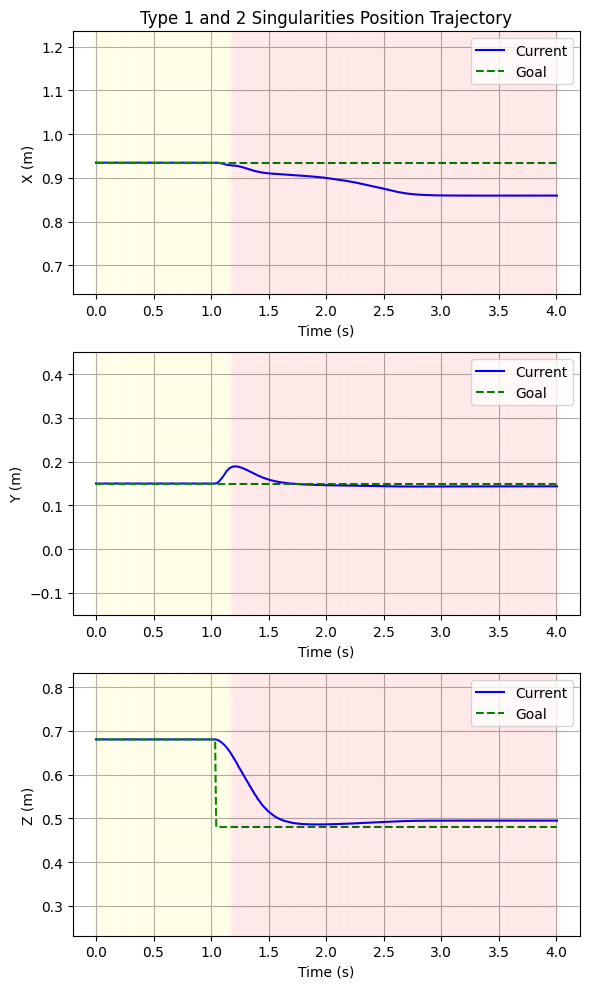

In [135]:
"""
    Plot data 
"""

# Plot ee vs. goal position 
fig, axes = plt.subplots(3, 1, figsize=(6, 10))
for i in range(3):
    axes[i].plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], \
                    df[ee_pos_columns[i]][START_INDICES[exp_index]:END_INDICES[exp_index]], color='b', label='Current')
    axes[i].plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], \
                    df[goal_pos_columns[i]][START_INDICES[exp_index]:END_INDICES[exp_index]], color='g', linestyle='--', label='Goal')

    # Plot vertical yellow bars
    # for j in range(len(s_indices)):
        # if s_indices[j] != 0:
        
    for j in s_indices_type2:
        axes[i].axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='yellow', linestyle='-', linewidth=6, alpha=0.01)
    for j in s_indices_type1:
        if j not in s_indices_type2:
            axes[i].axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='red', linestyle='-', linewidth=6, alpha=0.01)

    # for j in s_indices_type2:
    #     axes[i].axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='red', linestyle='-', linewidth=2, alpha=0.005)

    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel(YLABELS[i])
    # axes[i].set_title(LABELS[exp_index])
    # axes[i].legend(loc="lower right")
    # axes[i].legend(loc="upper left")
    axes[i].legend(loc="upper right")
    axes[i].grid() 
    
    # Use range for equal spacing
    goal_val = np.mean(df[goal_pos_columns[i]][START_INDICES[exp_index]:END_INDICES[exp_index]])
    if i == 0:
        axes[i].set_ylim([goal_val - 0.3, goal_val + 0.3])
    elif i == 1:
        axes[i].set_ylim([goal_val - 0.3, goal_val + 0.3])
    elif i == 2:
        axes[i].set_ylim([goal_val - 0.3, goal_val + 0.3])

axes[0].set_title(LABELS[exp_index] + ' Position Trajectory')
plt.tight_layout()
plt.show()

# # Plot ee vs. goal position all in one plot 
# fig, axes = plt.subplots(1, 1, figsize=(10, 10))
# axes.plot(df['time'], df[ee_pos_columns[0]], color='b')
# axes.plot(df['time'], df[goal_pos_columns[0]], color='g', linestyle='--')

# axes.plot(df['time'], df[ee_pos_columns[1]], color='b')
# axes.plot(df['time'], df[goal_pos_columns[1]], color='g', linestyle='--')

# axes.plot(df['time'], df[ee_pos_columns[2]], color='b')
# axes.plot(df['time'], df[goal_pos_columns[2]], color='g', linestyle='--')

# # Plot vertical yellow bars
# # for j in range(len(s_indices)):
#     # if s_indices[j] != 0:
# for i in s_indices:
#     axes.axvline(x=df['time'][i], color='red', linestyle='-', linewidth=5, alpha=0.01)

# axes.set_xlabel('Time (s)')
# axes.set_ylabel(YLABELS[0])
# axes.set_title(LABELS[exp_index])
# axes.legend()
# axes.grid() 

# plt.tight_layout()



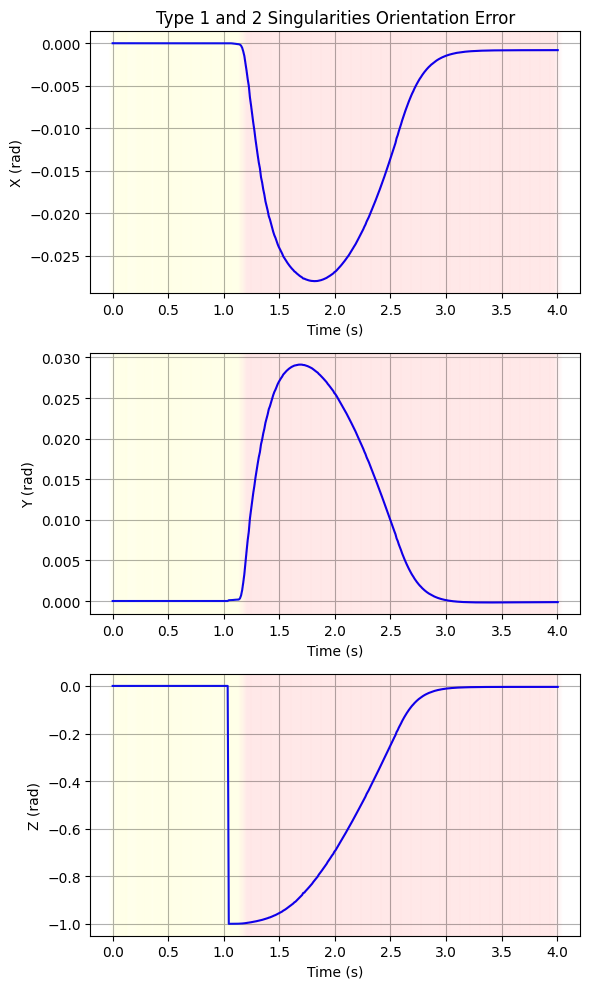

In [ ]:
# Plot orientation error 
fig, axes = plt.subplots(3, 1, figsize=(6, 10))
for i in range(3):
    axes[i].plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], \
                 df[ori_error_columns[i]][START_INDICES[exp_index]:END_INDICES[exp_index]], color='b')

    # Plot vertical yellow bars
    # for j in range(len(s_indices)):
        # if s_indices[j] != 0:
        # axes[i].axvline(x=df['time'][s_indices[j]], color='red', linestyle='-', linewidth=5, alpha=0.01)
    # for j in s_indices_type1:
    #     axes[i].axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='red', linestyle='-', linewidth=9, alpha=0.008)
    
    for j in s_indices_type2:
        axes[i].axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='yellow', linestyle='-', linewidth=6, alpha=0.01)
    for j in s_indices_type1:
        if j not in s_indices_type2:
            axes[i].axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='red', linestyle='-', linewidth=6, alpha=0.01)
            
    goal_val = np.mean(df[goal_pos_columns[i]][START_INDICES[exp_index]:END_INDICES[exp_index]])
    if i == 0:
        axes[i].set_ylim([goal_val - 0.3, goal_val + 0.3])
    elif i == 1:
        axes[i].set_ylim([goal_val - 0.3, goal_val + 0.3])
    elif i == 2:
        axes[i].set_ylim([goal_val - 0.3, goal_val + 0.3])

    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel(ORI_YLABELS[i])
    # axes[i].set_title(LABELS[exp_index])
    # axes[i].legend()
    axes[i].grid() 

axes[0].set_title(LABELS[exp_index] + ' Orientation Error')

plt.tight_layout()
plt.show()

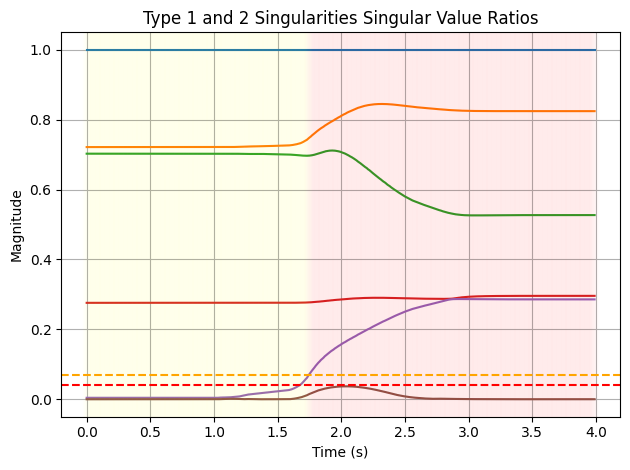

In [128]:
# Plot s value ratios
# svalue_ratios = np.abs(df[svalue_columns][START_INDICES[exp_index]:END_INDICES[exp_index]].to_numpy(dtype=np.float64))
# normalized_matrix = svalue_ratios / svalue_ratios.max(axis=1, keepdims=True)

# print(normalized_matrix[0])

# manual fix for type 1 
# normalized_matrix[3262][:] = normalized_matrix[3262 - 1][:]

fig, axes = plt.subplots(1, 1)
axes.plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], normalized_matrix[:, 0], label="S1")
axes.plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], normalized_matrix[:, 1], label="S2")
axes.plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], normalized_matrix[:, 2], label="S3")
axes.plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], normalized_matrix[:, 3], label="S4")
axes.plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], normalized_matrix[:, 4], label="S5")
axes.plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], normalized_matrix[:, 5], label="S6")

# for j in s_indices_type1:
    # axes.axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='red', linestyle='-', linewidth=10, alpha=0.008)
    
for j in s_indices_type2:
    axes.axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='yellow', linestyle='-', linewidth=6, alpha=0.01)
for j in s_indices_type1:
    if j not in s_indices_type2:
        axes.axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='red', linestyle='-', linewidth=6, alpha=0.01)

# Draw horizontal dashed lines
# axes.axhline(y=linear_s_values[0], color='red', linestyle='--')
# axes.axhline(y=linear_s_values[1], color='orange', linestyle='--')
axes.axhline(y=combined_s_values[0], color='red', linestyle='--')
axes.axhline(y=combined_s_values[1], color='orange', linestyle='--')

axes.set_xlabel('Time (s)')
axes.set_ylabel('Magnitude')
axes.set_title(LABELS[exp_index] + ' Singular Value Ratios')
# axes.legend()
axes.grid() 

plt.tight_layout()
plt.show()

In [99]:
# Plot singular vs. strategy torques for a joint 
joint_index = 6  # type 2 singularity 
# joint_index = 3
# singular_joint_torque = df[singular_task_torques_columns[joint_index]][START_INDICES[exp_index]:END_INDICES[exp_index]]
non_singular_joint_torque = df[non_singular_task_torques_columns[joint_index]][START_INDICES[exp_index]:END_INDICES[exp_index]]
motion_force_joint_torque = df[motion_task_torques_columns[joint_index]][START_INDICES[exp_index]:END_INDICES[exp_index]]
joint_strategy_torque = df[joint_strategy_torques_columns[joint_index]][START_INDICES[exp_index]:END_INDICES[exp_index]]
nonhandling_torque = df[nonhandling_torque_columns[joint_index]][START_INDICES[exp_index]:END_INDICES[exp_index]]
singular_joint_torque = motion_force_joint_torque - non_singular_joint_torque - joint_strategy_torque
fig, axes = plt.subplots(1, 1)
axes.plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], non_singular_joint_torque + nonhandling_torque, label='Without Strategy')
axes.plot(df['time'][START_INDICES[exp_index]:END_INDICES[exp_index]] - df['time'][START_INDICES[exp_index]], motion_force_joint_torque, label='With Strategy')

# Plot vertical yellow bars
# for j in range(len(s_indices)):
    # if s_indices[j] != 0:
    # axes.axvline(x=df['time'][s_indices[j]], color='red', linestyle='-', linewidth=5, alpha=0.01)
for j in s_indices:
    axes.axvline(x=df['time'][j] - df['time'][START_INDICES[exp_index]], color='red', linestyle='-', linewidth=2, alpha=0.01)

axes.set_xlabel('Time (s)')
axes.set_ylabel('Torque (N-m)')
axes.set_ylim([-60, 60])
axes.set_title(LABELS[exp_index] + ' Joint ' + str(joint_index + 1) + ' Torque With And Without Strategy')
axes.legend(loc='lower left')
axes.grid() 

print(np.max(singular_joint_torque))

plt.tight_layout()  # Adjust spacing to prevent overlap
plt.show() 

IndexError: list index out of range

In [92]:
# Example usage
# plot("./data/type_2_wrist.csv", 0, 0)
# plot("../../build/examples/18-panda_singularity/type_1.csv", 3, 0)
# plot("../../build/examples/18-panda_singularity/type_2_overhead.csv", 0, 0)
# plot("../../build/examples/18-panda_singularity/type_2_wrist.csv", 0, 0)
plot("./data/03-31/revised-bounds/type_2_wrist.csv", 0, 1)
plt.show()

NameError: name 'plot' is not defined